# DQN Return Plots

This notebook creates:
- CartPole: eval return vs environment steps
- LunarLander: eval return vs environment steps
- MsPacman: train return and eval return on the same axes
- LunarLander hyperparameter comparison: all four eval-return curves on one graph

In [ ]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt

In [ ]:
def load_metric_curve(log_csv_path, metric_name):
    steps = []
    values = []

    with open(log_csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            step = row.get("step", "")
            value = row.get(metric_name, "")

            if not step or not value:
                continue

            steps.append(float(step))
            values.append(float(value))

    if not steps:
        raise ValueError(f"No points found for {metric_name} in {log_csv_path}")

    return steps, values


exp_dir = Path("../exp")
patterns = {
    "CartPole": "CartPole-v1_dqn_*/log.csv",
    "LunarLander": "LunarLander-v2_dqn_*/log.csv",
    "MsPacman": "MsPacman_dqn_*/log.csv",
}

env_to_log = {}
for env_name, pattern in patterns.items():
    matches = sorted(exp_dir.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"Missing log for {env_name}: {pattern}")
    env_to_log[env_name] = matches[-1]

env_to_log

In [ ]:
for env_name in ["CartPole", "LunarLander"]:
    log_path = env_to_log[env_name]
    steps, eval_returns = load_metric_curve(log_path, "Eval_AverageReturn")

    plt.figure(figsize=(8, 5))
    plt.plot(steps, eval_returns, marker="o", linewidth=2, label="Eval Return")
    plt.xlabel("Environment Steps")
    plt.ylabel("Return")
    plt.title(f"{env_name} DQN Evaluation Return")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
pacman_log_path = env_to_log["MsPacman"]
train_steps, train_returns = load_metric_curve(pacman_log_path, "Train_EpisodeReturn")
eval_steps, eval_returns = load_metric_curve(pacman_log_path, "Eval_AverageReturn")

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_returns, linewidth=1.2, alpha=0.7, label="Train Return")
plt.plot(eval_steps, eval_returns, marker="o", linewidth=2, label="Eval Return")
plt.xlabel("Environment Steps")
plt.ylabel("Return")
plt.title("MsPacman DQN Train and Eval Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## LunarLander Hyperparameter Comparison

This plot overlays the LunarLander evaluation curves for four runs:
- baseline
- hidden size = 512
- learning rate = 0.0003
- target update period = 250

In [8]:
baseline_like_logs = sorted(exp_dir.glob("LunarLander-v2_dqn_sd1_*/log.csv"))
if len(baseline_like_logs) < 2:
    raise ValueError("Expected two LunarLander runs with exp_name=dqn: baseline and hidden-size variant")

lunarlander_runs = {
    "baseline": baseline_like_logs[0],
    "hidden_size_512": baseline_like_logs[-1],
    "learning_rate_0.0003": sorted(exp_dir.glob("LunarLander-v2_dqn_lr_0p0003_sd1_*/log.csv"))[-1],
    "target_update_250": sorted(exp_dir.glob("LunarLander-v2_dqn_target_update_250_sd1_*/log.csv"))[-1],
}

lunarlander_runs

{'baseline': PosixPath('../exp/LunarLander-v2_dqn_sd1_20260311_161348/log.csv'),
 'hidden_size_512': PosixPath('../exp/LunarLander-v2_dqn_sd1_20260311_174136/log.csv'),
 'learning_rate_0.0003': PosixPath('../exp/LunarLander-v2_dqn_lr_0p0003_sd1_20260311_175258/log.csv'),
 'target_update_250': PosixPath('../exp/LunarLander-v2_dqn_target_update_250_sd1_20260311_180517/log.csv')}

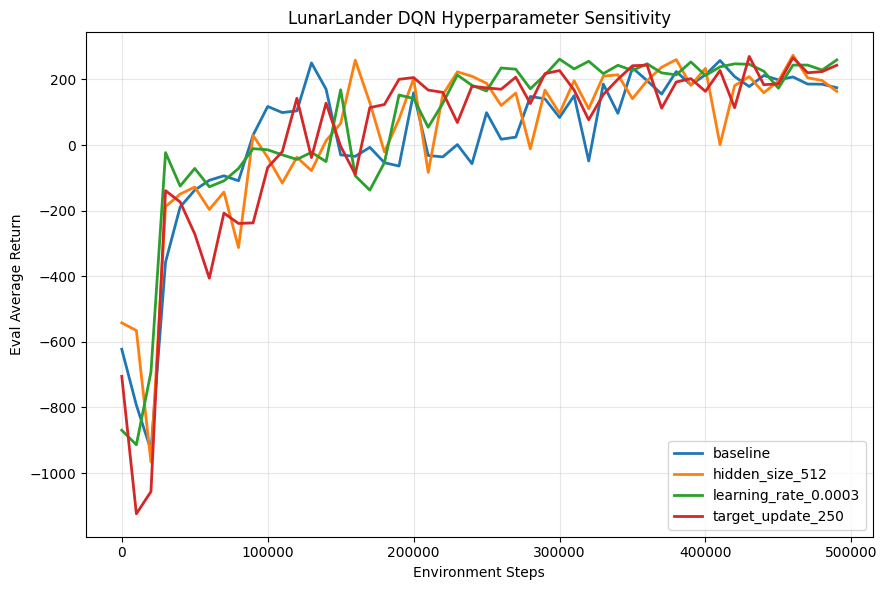

In [9]:
plt.figure(figsize=(9, 6))

for label, log_path in lunarlander_runs.items():
    steps, eval_returns = load_metric_curve(log_path, "Eval_AverageReturn")
    plt.plot(steps, eval_returns, linewidth=2, label=label)

plt.xlabel("Environment Steps")
plt.ylabel("Eval Average Return")
plt.title("LunarLander DQN Hyperparameter Sensitivity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()